<a href="https://colab.research.google.com/github/trsantanarural/predicao-falhas-tarefas/blob/main/notebooks/03_analise_exploratoria.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 03. Análise exploratória

**Entrada:** `saida/base_modelagem.parquet` (notebook 02)
**Saídas:** figuras em `figuras/`

Conjuntos: treino = dias 1 a 19, validação = dias 20 a 23, teste = dias 24 a 29. As estatísticas por classe usam apenas o treino e a validação (dias 1 a 23), para não usar o teste na análise.

## 1. Configuração do ambiente

In [46]:
from google.colab import drive
drive.mount('/content/drive')

import os, time
import numpy as np
import pandas as pd

# Pasta de trabalho no Google Drive (dados intermediários e figuras)
BASE = '/content/drive/MyDrive/artigo_predicao'
for d in ['ev_parts', 'uso_parts', 'saida', 'figuras']:
    os.makedirs(f'{BASE}/{d}', exist_ok=True)

KEY = ['job_id', 'task_index']   # identificador de uma tarefa no trace
FRAC = 10                        # amostra: jobs com job_id % 10 == 0 (~10% dos jobs)

import matplotlib.pyplot as plt
import seaborn as sns
FIG = f'{BASE}/figuras'

base = pd.read_parquet(f'{BASE}/saida/base_modelagem.parquet')
base['conjunto'] = np.where(base.dia >= 24, 'teste', np.where(base.dia >= 20, 'validação', 'treino'))

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Estilo das figuras

In [47]:
import matplotlib.pyplot as plt
import numpy as np
AZUL, LARANJA = '#2a78d6', '#eb6834'
TXT, TXT2, GRADE = '#0b0b0b', '#52514e', '#e4e3df'
plt.rcParams.update({
    'font.size': 10, 'axes.edgecolor': TXT2, 'axes.labelcolor': TXT, 'xtick.color': TXT2,
    'ytick.color': TXT2, 'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.color': GRADE, 'grid.linewidth': 0.6, 'axes.axisbelow': True,
    'figure.facecolor': 'white', 'axes.facecolor': 'white', 'savefig.bbox': 'tight'})

## 2. Tamanho e taxa de falha por conjunto

In [48]:
base.groupby('conjunto').falha.agg(['size', 'sum', 'mean'])

,size,sum,mean
conjunto,,,
teste,134744,9064,0.067268
treino,475204,30145,0.063436
validação,114401,6836,0.059755


## 3. Taxa de falha por dia do trace
Faixas sombreadas indicam os períodos de validação (dias 20 a 23) e de teste (dias 24 a 29); a linha tracejada é a taxa média dos dias 1 a 23.

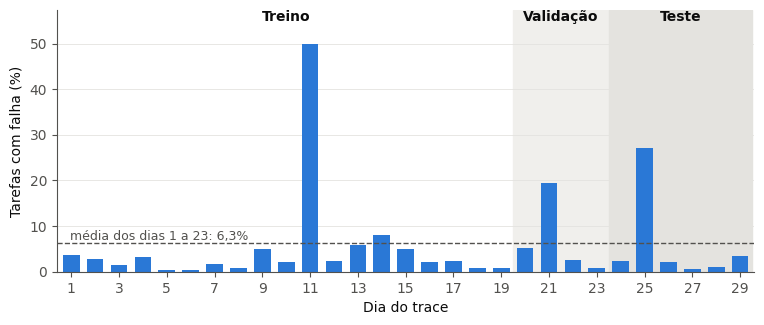

In [49]:
d = base.groupby('dia').falha.mean() * 100
media_trein = base[base.dia <= 23].falha.mean() * 100
fig, ax = plt.subplots(figsize=(9, 3.4))
ax.axvspan(19.5, 23.5, color='#f0efec', zorder=0)
ax.axvspan(23.5, 29.5, color='#e4e3df', zorder=0)
ax.bar(d.index, d.values, width=0.7, color=AZUL, zorder=2)
ax.axhline(media_trein, ls='--', lw=1, color=TXT2, zorder=3)
ax.text(0.8, media_trein, f' média dos dias 1 a 23: {media_trein:.1f}%'.replace('.', ','), va='bottom', fontsize=9, color=TXT2)
ymax = d.max() * 1.15
for x, rot in [(10, 'Treino'), (21.5, 'Validação'), (26.5, 'Teste')]:
    ax.text(x, ymax, rot, ha='center', va='top', fontsize=10, color=TXT, fontweight='bold')
ax.set_ylim(0, ymax); ax.set_xlim(0.4, 29.6)
ax.set_xticks(range(1, 30, 2)); ax.grid(axis='x', visible=False)
ax.set_xlabel('Dia do trace'); ax.set_ylabel('Tarefas com falha (%)')
fig.savefig(f'{FIG}/taxa_falha_dia.png', dpi=200)
plt.show()

## 4. Concentração das tarefas com falha por job

In [50]:
fj = base[base.falha == 1].groupby('job_id').size().sort_values(ascending=False)
print('jobs com falha:', len(fj), '| os 10 maiores concentram', round(fj.head(10).sum() / fj.sum(), 3), 'das falhas')
print(fj.head(10).to_string())

jobs com falha: 796 | os 10 maiores concentram 0.756 das falhas
job_id
6337545460    19579
6449919400     6655
6418746280     3115
6414778640     1391
6420299240      884
6316758500      833
6357618720      645
6304918650      612
6361680850      566
6270648320      548


## 5. Valores ausentes de CPI e MAI e sua relação com a falha

In [51]:
for c in ['cpi', 'mai']:
    print(c, base.groupby(base[c].isna()).falha.agg(['size', 'mean']).to_dict())

cpi {'size': {False: 598532, True: 125817}, 'mean': {False: 0.07520232836339577, True: 0.008218285287361803}}
mai {'size': {False: 581146, True: 143203}, 'mean': {False: 0.07385063305950657, True: 0.02183613471784809}}


## 6. Medianas dos atributos por classe (dias 1 a 23)

In [52]:
FEAT = ['priority','scheduling_class','cpu_req','ram_req','disk_req','cpu_rate','canonical_mem',
        'assigned_mem','unmapped_cache','total_cache','disk_space','cpi','mai','sampled_cpu',
        'max_mem','max_cpu','tempo_obs','n_janelas']
tr = base[base.dia <= 23]
print(tr.groupby('falha')[FEAT].median().T.round(4).to_string())

falha                    0         1
priority               4.0       1.0
scheduling_class       0.0       0.0
cpu_req            0.03024    0.0125
ram_req             0.0318    0.0159
disk_req           0.00027  0.000404
cpu_rate          0.014913  0.003692
canonical_mem     0.004233  0.004104
assigned_mem      0.005298  0.005983
unmapped_cache    0.000172  0.001159
total_cache       0.000306  0.001319
disk_space             0.0  0.000008
cpi                  1.568  3.111787
mai               0.002493  0.007197
sampled_cpu       0.014139  0.004148
max_mem           0.009125  0.005356
max_cpu              0.136   0.07812
tempo_obs            807.0    1036.0
n_janelas              4.0       4.0


### 7.1 Razão entre medianas (falha ÷ conclusão), com e sem os jobs dominantes
Barras à direita de 1× indicam atributos com mediana maior nas tarefas que falharam; à esquerda, menor. Em azul, todos os jobs; em laranja, sem os 3 jobs com mais falhas (parte 4). Prioridade e classe de escalonamento, ordinais, estão na tabela da seção 6. Escala logarítmica.

Fora do gráfico (mediana zero em alguma classe): []
                                 todos  sem_top
CPU solicitada                    0.41     1.00
Memória solicitada                0.50     0.80
Disco solicitado                  1.50     0.43
CPU média                         0.25     1.24
Memória canônica                  0.97     1.02
Memória atribuída                 1.13     0.99
Cache não mapeado                 6.75     0.98
Cache total                       4.31     1.32
Espaço em disco                  16.00     1.33
Ciclos por instrução              1.98     0.91
Acessos à memória por instrução   2.89     0.83
Amostra de CPU                    0.29     1.28
Memória máxima                    0.59     0.84
CPU máxima                        0.57     0.81
Tempo observado                   1.28     2.63
Nº de janelas                     1.00     2.25


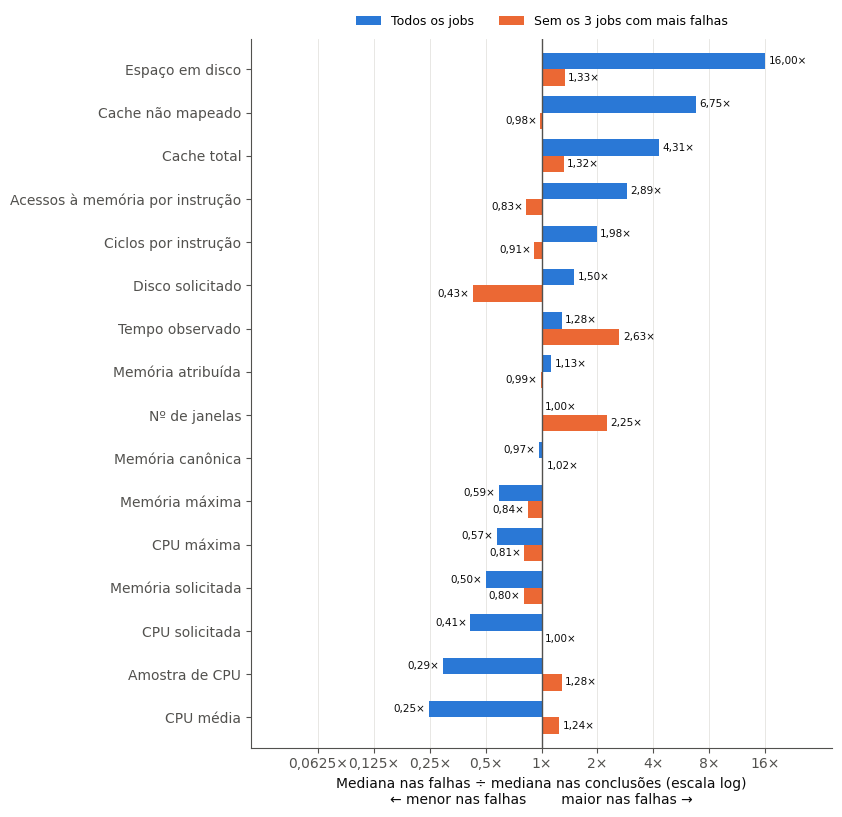

In [53]:
# Atributos contínuos comparados; prioridade e classe de escalonamento (ordinais) ficam na tabela da seção 6
CONT = ['cpu_req','ram_req','disk_req','cpu_rate','canonical_mem','assigned_mem','unmapped_cache',
        'total_cache','disk_space','cpi','mai','sampled_cpu','max_mem','max_cpu','tempo_obs','n_janelas']
top3 = fj.head(3).index                      # 3 jobs com mais falhas (parte 4)

def razao(df):
    m = df.groupby('falha')[CONT].median().T
    return (m[1] / m[0]).where((m[0] > 0) & (m[1] > 0))

r = pd.DataFrame({'todos': razao(tr), 'sem_top': razao(tr[~tr.job_id.isin(top3)])}).dropna()
print('Fora do gráfico (mediana zero em alguma classe):', [NOMES[c] for c in CONT if c not in r.index])
print(r.round(2).rename(index=NOMES).to_string())
r = r.sort_values('todos')

fig, ax = plt.subplots(figsize=(7.5, 0.5 * len(r) + 1.2))
y = np.arange(len(r)); h = 0.38
ax.barh(y + h/2, np.log2(r['todos']), height=h, color=AZUL, label='Todos os jobs', zorder=2)
ax.barh(y - h/2, np.log2(r['sem_top']), height=h, color=LARANJA, label='Sem os 3 jobs com mais falhas', zorder=2)
ax.axvline(0, color=TXT2, lw=1)
for yi, (a, b) in zip(y, r[['todos', 'sem_top']].values):
    for val, dy in ((a, h/2), (b, -h/2)):
        ax.text(np.log2(val) + (0.06 if val >= 1 else -0.06), yi + dy, f'{val:.2f}×'.replace('.', ','),
                va='center', ha='left' if val >= 1 else 'right', fontsize=7.5, color=TXT)
lim = np.abs(np.log2(r.values)).max() * 1.3
ax.set_xlim(-lim, lim); ax.set_ylim(-0.7, len(r) - 0.3)
tk = [t for t in range(-4, 5) if abs(t) <= lim]
ax.set_xticks(tk); ax.set_xticklabels([f'{2.0**t:g}×'.replace('.', ',') for t in tk])
ax.set_yticks(y); ax.set_yticklabels([NOMES[c] for c in r.index]); ax.grid(axis='y', visible=False)
ax.set_xlabel('Mediana nas falhas ÷ mediana nas conclusões (escala log)\n← menor nas falhas        maior nas falhas →')
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=2, frameon=False, fontsize=9)
fig.savefig(f'{FIG}/razao_medianas.png', dpi=200)
plt.show()

### 7.2 Distribuições por classe (escala log)
Caixas com mediana e quartis; valores extremos omitidos. A escala logarítmica evita que as caudas longas comprimam as caixas.

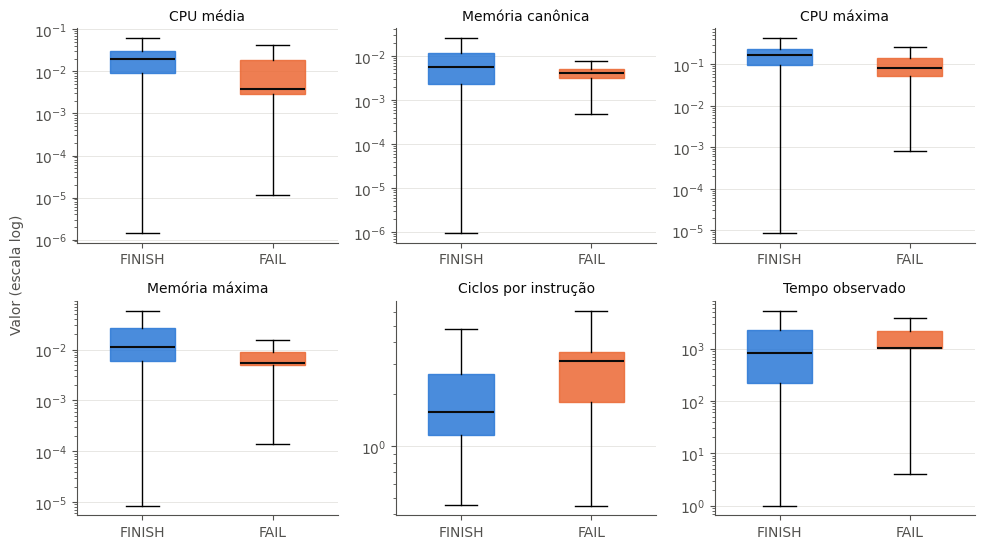

In [54]:
sel = ['cpu_rate', 'canonical_mem', 'max_cpu', 'max_mem', 'cpi', 'tempo_obs']
am = tr.sample(min(200_000, len(tr)), random_state=42)
fig, axs = plt.subplots(2, 3, figsize=(10, 5.6))
for ax, c in zip(axs.flat, sel):
    dados = [am.loc[am.falha == k, c].dropna() for k in (0, 1)]
    dados = [v[v > 0] for v in dados]
    bp = ax.boxplot(dados, widths=0.5, showfliers=False, patch_artist=True,
                    medianprops=dict(color=TXT, lw=1.5))
    for patch, cor in zip(bp['boxes'], (AZUL, LARANJA)):
        patch.set_facecolor(cor); patch.set_alpha(0.85); patch.set_edgecolor(cor)
    ax.set_yscale('log'); ax.set_title(NOMES[c], fontsize=10, color=TXT)
    ax.set_xticks([1, 2]); ax.set_xticklabels(['FINISH', 'FAIL']); ax.grid(axis='x', visible=False)
fig.supylabel('Valor (escala log)', fontsize=10, color=TXT2)
fig.tight_layout()
fig.savefig(f'{FIG}/atributos_por_classe.png', dpi=200)
plt.show()

## 8. Jobs dominantes: período e sobreposição entre treino e teste
Verifica em que dias ficam os 10 jobs com mais falhas, se algum job tem tarefas em mais de um conjunto (treino, validação, teste) e quanto as falhas do teste se concentram em poucos jobs.

In [55]:
top = fj.head(10).index
info = (base[base.job_id.isin(top)].groupby('job_id')
        .agg(tarefas=('falha', 'size'), falhas=('falha', 'sum'),
             dia_min=('dia', 'min'), dia_max=('dia', 'max')))
info['taxa'] = (info.falhas / info.tarefas).round(3)
print(info.sort_values('falhas', ascending=False).to_string())

jc = base.groupby('job_id').conjunto.nunique()
print('jobs em mais de um conjunto:', int((jc > 1).sum()),
      '| tarefas desses jobs:', int(base.job_id.isin(jc[jc > 1].index).sum()))

ft = base[(base.conjunto == 'teste') & (base.falha == 1)].groupby('job_id').size().sort_values(ascending=False)
print('teste: jobs com falha:', len(ft), '| os 3 maiores concentram', round(ft.head(3).sum() / ft.sum(), 3))
print(ft.head(5).to_string())

            tarefas  falhas  dia_min  dia_max   taxa
job_id                                              
6337545460    19579   19579       11       11  1.000
6449919400     6655    6655       25       25  1.000
6418746280     3115    3115       21       21  1.000
6414778640     2064    1391       20       21  0.674
6420299240      884     884       21       21  1.000
6316758500      833     833        9        9  1.000
6357618720     1135     645       13       14  0.568
6304918650     1098     612        7        8  0.557
6361680850     2386     566       14       14  0.237
6270648320     7636     548        2        2  0.072
jobs em mais de um conjunto: 9 | tarefas desses jobs: 11475
teste: jobs com falha: 209 | os 3 maiores concentram 0.823
job_id
6449919400    6655
6441348810     494
6461364680     313
6479443460     269
6448476500     189


### 8.1 Medianas por classe sem os 3 maiores jobs
Verifica se as diferenças entre as classes da seção 6 se mantêm quando se retiram os jobs que concentram a maior parte das falhas.

In [56]:
top3 = fj.head(3).index
sem_top = tr[~tr.job_id.isin(top3)]
print('falhas no treino sem os 3 maiores jobs:', int(sem_top.falha.sum()))
print(sem_top.groupby('falha')[FEAT].median().T.round(4).to_string())

falhas no treino sem os 3 maiores jobs: 14287
falha                    0         1
priority               4.0       0.0
scheduling_class       0.0       0.0
cpu_req            0.03024   0.03024
ram_req             0.0318   0.02545
disk_req           0.00027  0.000115
cpu_rate          0.014913  0.018556
canonical_mem     0.004233  0.004317
assigned_mem      0.005298  0.005264
unmapped_cache    0.000172  0.000169
total_cache       0.000306  0.000404
disk_space             0.0  0.000001
cpi                  1.568  1.430975
mai               0.002493  0.002066
sampled_cpu       0.014139  0.018147
max_mem           0.009125  0.007706
max_cpu              0.136    0.1099
tempo_obs            807.0    2120.0
n_janelas              4.0       9.0
